# Load packages

In [17]:
import pandas as pd
import numpy as np

import os
import glob

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# Load data

In [41]:
slides = ['19_02_02A', '19_02_01A', 'T2', 'INF2', '19_02_03A', '1B', '2B', '3B', 'INF1']

In [44]:
# Create an empty list to store dataframes
all_dfs = []

# Path where the CSV files are stored
base_path = '/Volumes/group/h345/afarkkilab/Data/17_Auria_TMA/Giotto_results/'

# Iterate through slides
for slide in slides:
    # Find all core files for this slide
    pattern = os.path.join(base_path, f'*_*{slide}*.csv')
    core_files = glob.glob(pattern)
    
    if not core_files:
        print(f"No files found for slide {slide}")
        continue
    
    print(f"Found {len(core_files)} core files for slide {slide}")
    
    # Process each core file
    for file_path in core_files:
        try:
            # Extract core name from file path
            core_name = os.path.basename(file_path).split('_')[2].replace('.csv', '')
            
            # Read the CSV file
            core_df = pd.read_csv(file_path)
            
            # Filter data
            core_df = core_df[core_df['feats'] == 'GCLC']
            core_df = core_df[core_df['int_cell_type'].isin(['EMT', 'Tumor'])]

            core_df['int_cell_type'] = core_df['int_cell_type'].replace({
                'EMT': 'VIM+Tumor',
                'Tumor': 'VIM-Tumor'
            })
            
            core_df = core_df[~core_df['cell_type'].isin(['EMT', 'Tumor', 'Other'])]
            
            core_df = core_df[['feats', 'cell_type', 'int_cell_type', 'log2fc', 'p.value', 'p.adj']]
            
            # Add 'slides' and 'core' columns
            core_df['slide'] = slide
            core_df['core'] = core_name
            
            # Append to the list of dataframes
            all_dfs.append(core_df)
            print(f"  Processed core {core_name}: {len(core_df)} rows")
        except Exception as e:
            print(f"  Error processing file {file_path}: {e}")

# Combine all dataframes into one
combined_df = pd.concat(all_dfs, ignore_index=True)


Found 32 core files for slide 19_02_02A
  Processed core core9: 10 rows
  Processed core core8: 11 rows
  Processed core core77: 11 rows
  Processed core core7: 10 rows
  Processed core core67: 12 rows
  Processed core core62: 12 rows
  Processed core core6: 8 rows
  Processed core core55: 10 rows
  Processed core core54: 10 rows
  Processed core core5: 12 rows
  Processed core core47: 12 rows
  Processed core core46: 12 rows
  Processed core core45: 12 rows
  Processed core core41: 11 rows
  Processed core core4: 11 rows
  Processed core core37: 14 rows
  Processed core core36: 14 rows
  Processed core core33: 14 rows
  Processed core core32: 14 rows
  Processed core core31: 14 rows
  Processed core core30: 14 rows
  Processed core core27: 12 rows
  Processed core core26: 11 rows
  Processed core core25: 13 rows
  Processed core core24: 11 rows
  Processed core core19: 7 rows
  Processed core core18: 7 rows
  Processed core core17: 6 rows
  Processed core core15: 14 rows
  Processed c

In [45]:
combined_df.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Giotto_combined_data.csv', index=False)

# combined_df

In [2]:
combined_df = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Giotto_combined_data.csv')

In [3]:
combined_df['int_cell_type'].unique()

array(['VIM-Tumor', 'VIM+Tumor'], dtype=object)

In [4]:
combined_df['interaction'] = combined_df['cell_type'] + '_' + combined_df['int_cell_type']

In [5]:
combined_df

,feats,cell_type,int_cell_type,log2fc,p.value,p.adj,slide,core,interaction
0,GCLC,Immune,VIM-Tumor,-0.176334,0.000,0.000,19_02_02A,core9,Immune_VIM-Tumor
1,GCLC,CD206.Macrophages,VIM-Tumor,-0.053626,0.192,0.192,19_02_02A,core9,CD206.Macrophages_VIM-Tumor
2,GCLC,CD206.Macrophages,VIM+Tumor,0.132036,0.064,0.128,19_02_02A,core9,CD206.Macrophages_VIM+Tumor
3,GCLC,Immune,VIM+Tumor,-0.005127,0.406,0.406,19_02_02A,core9,Immune_VIM+Tumor
4,GCLC,CD4.T.cells,VIM+Tumor,0.066246,0.074,0.074,19_02_02A,core9,CD4.T.cells_VIM+Tumor
...,...,...,...,...,...,...,...,...,...
4091,GCLC,CD206.Macrophages,VIM-Tumor,-0.213107,0.002,0.004,INF1,core1,CD206.Macrophages_VIM-Tumor
4092,GCLC,CD4.T.cells,VIM+Tumor,-0.078798,0.498,0.498,INF1,core1,CD4.T.cells_VIM+Tumor
4093,GCLC,FOXP3.CD4.Tregs,VIM+Tumor,0.080520,0.499,0.499,INF1,core1,FOXP3.CD4.Tregs_VIM+Tumor
4094,GCLC,FOXP3.CD4.Tregs,VIM-Tumor,-0.214678,0.250,0.494,INF1,core1,FOXP3.CD4.Tregs_VIM-Tumor


In [6]:
combined_df_summary = combined_df.groupby('interaction')['log2fc'].mean().reset_index()
combined_df_summary['Tumor_type'] = combined_df_summary['interaction'].apply(lambda x: x.split('_')[-1])
combined_df_summary['feats'] = 'GCLC'

In [7]:
combined_df_summary

,interaction,log2fc,Tumor_type,feats
0,CD206.Macrophages_VIM+Tumor,0.039364,VIM+Tumor,GCLC
1,CD206.Macrophages_VIM-Tumor,-0.065732,VIM-Tumor,GCLC
2,CD4.T.cells_VIM+Tumor,0.035854,VIM+Tumor,GCLC
3,CD4.T.cells_VIM-Tumor,-0.047075,VIM-Tumor,GCLC
4,CD68.Macrophages_VIM+Tumor,0.042793,VIM+Tumor,GCLC
5,CD68.Macrophages_VIM-Tumor,-0.069961,VIM-Tumor,GCLC
6,CD8.T.cells_VIM+Tumor,0.020665,VIM+Tumor,GCLC
7,CD8.T.cells_VIM-Tumor,-0.065563,VIM-Tumor,GCLC
8,FOXP3.CD4.Tregs_VIM+Tumor,0.020779,VIM+Tumor,GCLC
9,FOXP3.CD4.Tregs_VIM-Tumor,-0.053150,VIM-Tumor,GCLC


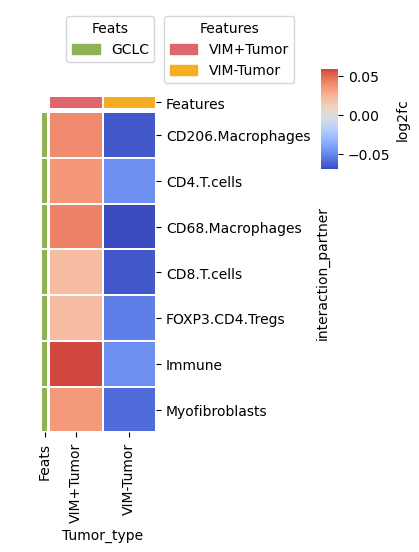

In [118]:

combined_df_summary['interaction_partner'] = combined_df_summary['interaction'].apply(
    lambda x: x.split('_')[0]
)

# Pivot the data to create a matrix suitable for heatmap
pivot_df = combined_df_summary.pivot(
    index='interaction_partner', 
    columns='Tumor_type', 
    values='log2fc'
)

feats = pd.Series("GCLC", index=pivot_df.index, name="feats")

feature_colors = {
    "VIM+Tumor": "#df676b",
    "VIM-Tumor": "#f6ad22"
}
col_colors = pd.DataFrame({
    "Features": pivot_df.columns.map(feature_colors)
}, index=pivot_df.columns)

row_colors = pd.DataFrame({
    "Feats": "#8fb257"
}, index=pivot_df.index)

g = sns.clustermap(
    pivot_df,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    figsize=(3.5, 5),
    annot=False,
    fmt=".2f",
    col_colors=col_colors,
    row_colors=row_colors,
    cbar_pos=(0.93, 0.65, 0.05, 0.2), # left, bottom, width, height
    cbar_kws={"label": "log2fc"},
    # log2fc of features in tumor cells interacting VS not interacting
    row_cluster=False,
    col_cluster=False
)


# Rotate x-axis labels 90 degrees
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90)

# Make row color bar wider
if hasattr(g, 'ax_row_colors'):
    pos = g.ax_row_colors.get_position()
    g.ax_row_colors.set_position([pos.x0, pos.y0, pos.width * 1.5, pos.height])

# Add legend for features (column colors)
feature_handles = [Patch(color=c, label=l) for l, c in feature_colors.items()]
feature_legend = plt.legend(
    handles=feature_handles,
    title="Features",
    loc="upper right",
    bbox_to_anchor=(-1.1, 1.6)
)
plt.gca().add_artist(feature_legend)

# Add legend for feats (row colors)
feats_handles = [Patch(color="#8fb257", label="GCLC")]
feats_legend = plt.legend(
    handles=feats_handles,
    title="Feats",
    loc="upper center",
    bbox_to_anchor=(-12, 1.6)
)

#plt.suptitle("Interaction partners log2fc for VIM+Tumor vs VIM-Tumor", y=1.05)
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/Giotto_heatmap_GCLC_2.pdf', bbox_inches='tight', dpi=500)
plt.show()
